# 🚀 Proyecto Final: Predicción de Churn en un Banco 🤖

**Autor:** Lucas Esquivel

**Curso:** Machine Learning para la Ciencia de Datos


## 1. Definición del Proyecto y Preguntas de Interés

### 1.1. Motivación y Audiencia
* ***Motivación:** Elegí este proyecto porque la predicción del churn (abandono de clientes) es un problema central en la industria bancaria. Retener clientes suele ser más rentable que adquirir nuevos, y anticipar qué clientes tienen mayor probabilidad de abandonar permite diseñar estrategias de fidelización más efectivas. Me interesa aplicar machine learning en este contexto para identificar patrones de comportamiento que expliquen por qué ciertos clientes deciden irse del banco, y cómo se puede actuar antes de que eso ocurra..*
  
* ***Audiencia:** Este proyecto está dirigido a equipos de marketing, analistas de datos y gerentes de fidelización de clientes en bancos u otras instituciones financieras. El objetivo es brindar un modelo que ayude a priorizar campañas de retención, optimizar recursos y reducir la tasa de abandono, con un impacto directo en la rentabilidad del negocio.*

### 1.2. Preguntas o Hipótesis Iniciales

* *Pregunta 1: ¿Podemos predecir con buena precisión qué clientes tienen mayor probabilidad de abandonar el banco?*
* *Pregunta 2: ¿Qué variables (edad, país, actividad, productos contratados, etc.) son las que más influyen en la decisión de un cliente de hacer churn?*
* *Pregunta 3: ¿Puede un modelo de machine learning ayudar a diseñar estrategias de retención más inteligentes?*

## 2. Adquisición de Datos (Data Acquisition)

1.  **Importamos las librerías que utilizaremos**

In [11]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score




2.  **Importamos el dataset que utilizaremos**

In [4]:
df = pd.read_csv("Churn_Modelling.csv")

print("Primeras filas del dataset:")
df.head()

Primeras filas del dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


3.  **Descripción de las features:**

* Customer ID: Identificador único de cada cliente.

* Surname: Apellido del cliente.

* Credit Score: Valor numérico que representa el puntaje crediticio del cliente.

* Geography: País de residencia del cliente (Francia, España o Alemania).

* Gender: Género del cliente (Masculino o Femenino).

* Age: Edad del cliente.

* Tenure: Número de años que el cliente lleva en el banco.

* Balance: Saldo de la cuenta del cliente.

* NumOfProducts: Número de productos bancarios que el cliente utiliza (ejemplo: cuenta de ahorros, tarjeta de crédito).

* HasCrCard: Indica si el cliente tiene tarjeta de crédito (1 = sí, 0 = no).

* IsActiveMember: Indica si el cliente es miembro activo (1 = sí, 0 = no).

* EstimatedSalary: Salario estimado del cliente.

* Exited: Variable objetivo. Indica si el cliente abandonó el banco (1 = sí, 0 = no).

## 3. EDA - Exploratory Data Analysis

1.  **Analizamos el dataset para entender sus features**

In [7]:
# Vemos que el dataset tiene 10.002 registros y que hay algunos campos que tienen al menos un registro nulo.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


In [9]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10002.000000,1.000200e+04,10002.000000,10001.000000,10002.000000,10002.000000,10002.000000,10001.000000,10001.000000,10002.000000,10002.000000
mean,5001.499600,1.569093e+07,650.555089,38.922311,5.012498,76491.112875,1.530194,0.705529,0.514949,100083.331145,0.203759
std,2887.472338,7.193177e+04,96.661615,10.487200,2.891973,62393.474144,0.581639,0.455827,0.499801,57508.117802,0.402812
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2501.250000,1.562852e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50983.750000,0.000000
50%,5001.500000,1.569073e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,1.000000,100185.240000,0.000000
75%,7501.750000,1.575323e+07,718.000000,44.000000,7.000000,127647.840000,2.000000,1.000000,1.000000,149383.652500,0.000000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


### Los principales insights que podemos hallar en el dataset gracias a los estadísticos que nos brinda la función .describe() son:

* El dataset contiene 10.000 clientes, de los cuales un 20% realizó churn y un 80% permaneció en el banco → el target está desbalanceado.
* Variables irrelevantes para la predicción: RowNumber, CustomerId y Surname (funcionan solo como identificadores).
* Edad (Age): promedio 39 años, rango 18–92 → clientes jóvenes y de mediana edad concentran la mayoría.
* Antigüedad (Tenure): promedio 5 años, rango 0–10 → no hay un sesgo fuerte hacia clientes muy nuevos o muy antiguos.
* Balance: promedio 76.491 pero con muchos clientes con saldo = 0 (25% del total) → posible factor explicativo de churn.
* Número de productos (NumOfProducts): la mayoría de clientes tiene 1 o 2 productos → podría influir en la permanencia.
* HasCrCard: el 71% tiene tarjeta de crédito → pero no necesariamente implica menor churn.
* IsActiveMember: ~51% son activos, ~49% inactivos → variable balanceada y potencialmente muy predictiva.
* EstimatedSalary: distribución casi uniforme entre 11 y 200k → no parece un factor determinante por sí solo.

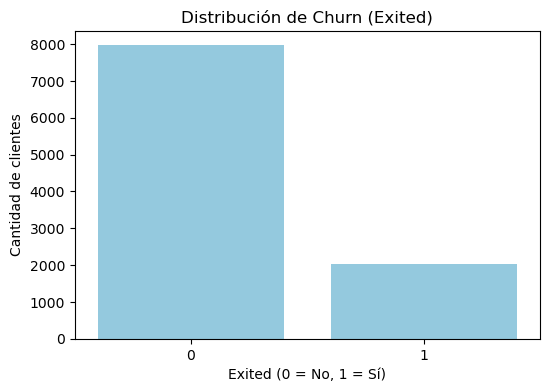

In [15]:
# Distribución de la variable target: Exited

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Exited", color="skyblue")
plt.title("Distribución de Churn (Exited)")
plt.xlabel("Exited (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de clientes")
plt.show()

En cuanto a la distribución de la variable target, como ya habíamos adelantado anteriormente, está desbalanceada. Aproximadamente el 80% no terminó en churn mientras que sólo el 20% sí abandonó.

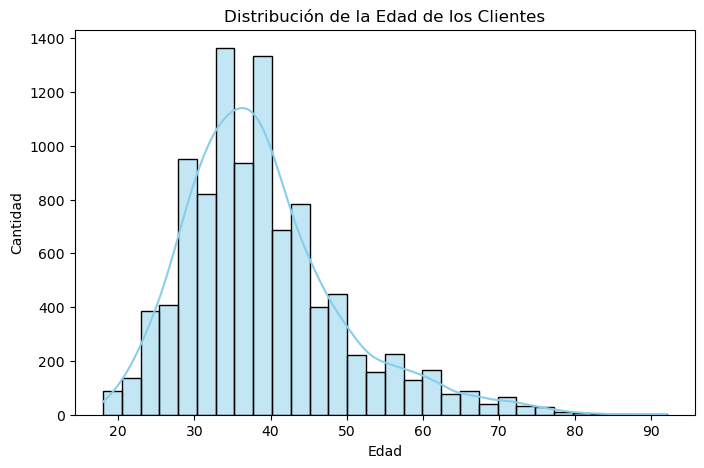

In [17]:
# Distribución de Edad

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True, color="skyblue")
plt.title("Distribución de la Edad de los Clientes")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.show()

En el histograma anterior podemos observar cómo la distribución por edad es una distribución normal que está alineada a la izquierda, lo que significa que la media está ubicada en el rango etario de entre 30 y 40 años. Esto ya lo habíamos adelantado con el .describe() que habíamos hecho previamente.

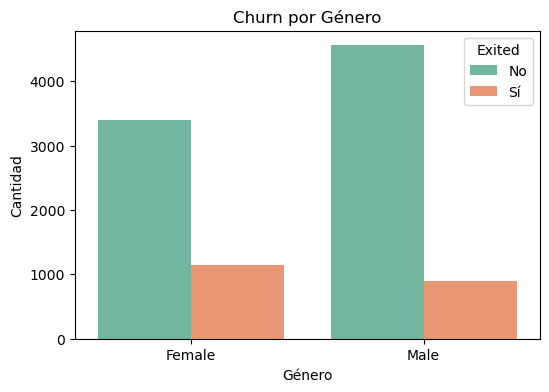

In [19]:
# Churn por Género
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Exited", palette="Set2")
plt.title("Churn por Género")
plt.xlabel("Género")
plt.ylabel("Cantidad")
plt.legend(title="Exited", labels=["No", "Sí"])
plt.show()

En cuanto al churn por género, vemos que los hombres tienen menor ratio de churn que las mujeres.

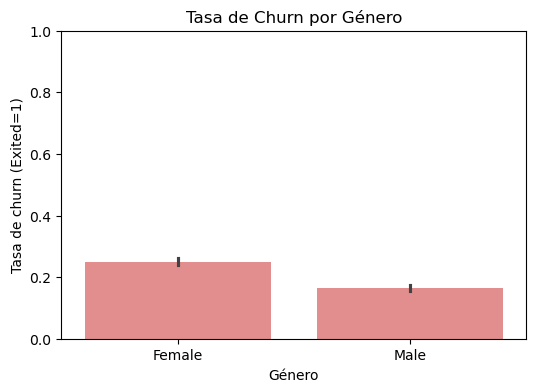

In [39]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="Gender",
    y="Exited",  
    estimator=lambda x: sum(x)/len(x),
    color="lightcoral"
)
plt.title("Tasa de Churn por Género")
plt.ylabel("Tasa de churn (Exited=1)")
plt.xlabel("Género")
plt.ylim(0, 1)
plt.show()

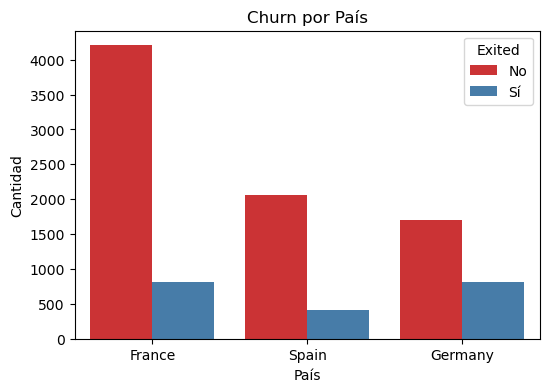

In [36]:
# Churn por País
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Geography", hue="Exited", palette="Set1")
plt.title("Churn por País")
plt.xlabel("País")
plt.ylabel("Cantidad")
plt.legend(title="Exited", labels=["No", "Sí"])
plt.show()

Del mismo modo, vemos que si bien Alemania es el país que menor cantidad de clientes tiene es el que mayor Tasa de Churn tiene si lo comparamos con España y Francia. 

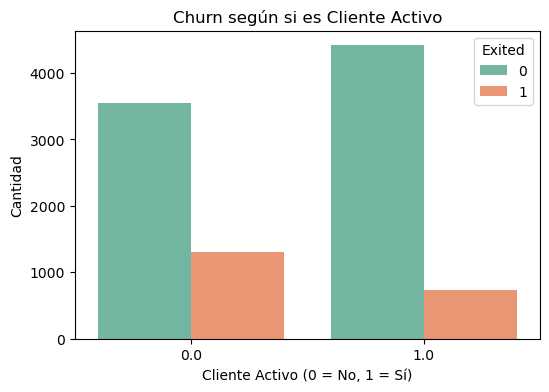

In [29]:
# Distribución del Churn entre clientes Activos e Inactivos.

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="IsActiveMember", hue="Exited", palette="Set2")
plt.title("Churn según si es Cliente Activo")
plt.xlabel("Cliente Activo (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")
plt.show()

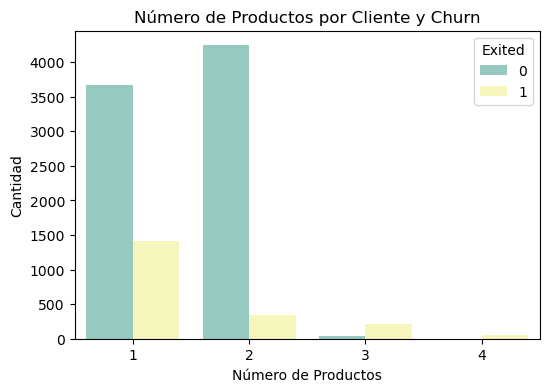

In [25]:
# Churn en relación a la cantidad de Productos por Cliente

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="NumOfProducts", hue="Exited", palette="Set3")
plt.title("Número de Productos por Cliente y Churn")
plt.xlabel("Número de Productos")
plt.ylabel("Cantidad")
plt.show()


Por último vemos que los clientes activos suelen tener menor tasa de churn lo que se alinea con el último gráfico, donde vemos que los clientes con 1 sólo producto tienen una tasa de churn mucho mayor que los que tienen 2 productos. Esto se explica ya que entendemos que los clientes con 2 productos son mucho más activos o suelen estar mucho más fidelizados que los clientes que tienen 1 solo producto, pueden caer en inactividad.

(Los que tienen 3 o 4 productos no los incluímos en el análisis ya que tienen muy pocos casos)

## 4. Feature Engeneering y Feature Selection

1.  **Eliminamos las features que creemos que serán irrelevantes para nuestro modelo predictivo.**

In [70]:
df = df.drop(columns=["CustomerId", "Surname"])
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
Index: 9998 entries, 0 to 10001
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9998 non-null   int64  
 1   CreditScore      9998 non-null   int64  
 2   Geography        9998 non-null   object 
 3   Gender           9998 non-null   object 
 4   Age              9998 non-null   float64
 5   Tenure           9998 non-null   int64  
 6   Balance          9998 non-null   float64
 7   NumOfProducts    9998 non-null   int64  
 8   HasCrCard        9998 non-null   float64
 9   IsActiveMember   9998 non-null   float64
 10  EstimatedSalary  9998 non-null   float64
 11  Exited           9998 non-null   int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 1015.4+ KB


2.  **Separamos las variables entre features y target, más adelante lo usaremos en el entrenamiento del modelo**

In [72]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

3.  **Identificamos las variables categóricas y las numéricas para luego preprocesarlas. A las variables categóricas les aplicaremos el método one hot encoding para convertirlas en numéricas y a las numéricas escalaremos para que todas estén bajo una misma escala y el modelo pueda utilizarlas de manera óptima.**

In [74]:
cat_features = ["Geography", "Gender"]
num_features = [col for col in X.columns if col not in cat_features]

4.  **Armamos nuestro preprocesador y lo aplicamos a las variables categoricas y numéricas.**

In [76]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

## 5. Entrenamiento y Desarrollo de Modelos.

Para el siguiente paso dividiremos nuestro dataset en train y test, luego entrenaremos distintos modelos y por último los compararemos para ver cuál es el que mejor performance tiene.

1.  **Dividimos el dataset en train y test**

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

2.  **Entrenamos los modelos. Además les corremos nuestro preprocesador para mejorar la efectividad de los mismos.**

In [80]:
# Modelo 1: Regresión Logística
log_reg = Pipeline(steps=[("preprocessor", preprocessor),
                          ("classifier", LogisticRegression(max_iter=1000))])
log_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['RowNumber', 'CreditScore',
                                                   'Age', 'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [82]:
# Modelo 2: Random Forest
rf = Pipeline(steps=[("preprocessor", preprocessor),
                     ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))])
rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['RowNumber', 'CreditScore',
                                                   'Age', 'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [88]:
# Modelo 3: XGBoost
xgb = Pipeline(steps=[("preprocessor", preprocessor),
                      ("classifier", XGBClassifier(
                          n_estimators=200,
                          learning_rate=0.1,
                          max_depth=5,
                          random_state=42,
                          use_label_encoder=False,
                          eval_metric="logloss"
                      ))])
xgb.fit(X_train, y_train)

C:\Users\Usuario\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:39:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['RowNumber', 'CreditScore',
                                                   'Age', 'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_b...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 6. Testeo y Evaluación de Modelos.

Desarrollamos una función para traer todas las métricas que necesitaremos para evaluar y comparar los resultados de cada modelo. Para medir la performance de cada uno y compararlos utilizaremos la curva ROC, Accuracy, Recall y el f1-Score. Además agregaremos la matriz de confusión para cada modelo, así podremos ver cómo se ubican los V-P, V-N, F-P y F-N.

In [90]:
def evaluar_modelo(model, nombre):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n===== {nombre} =====")
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))

In [96]:
# Evaluamos los tres modelos.
evaluar_modelo(log_reg, "Regresión Logística")
evaluar_modelo(rf, "Random Forest")
evaluar_modelo(xgb, "XGBoost")


===== Regresión Logística =====
ROC-AUC: 0.7753811951916445
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.96      0.89      1592
           1       0.55      0.20      0.30       408

    accuracy                           0.80      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.77      0.80      0.77      2000

Matriz de Confusión:
 [[1524   68]
 [ 325   83]]

===== Random Forest =====
ROC-AUC: 0.8623186397674647
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1592
           1       0.75      0.48      0.59       408

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Matriz de Confusión:
 [[1526   66]
 [ 212  196]]

===== XGBoost =====
ROC-AUC: 0.865483976253818
Classification Report:
             

## 7. Conclusión

Primero analizaremos el desempeño de cada modelo y luego daremos una conclusión final.

1.  **Regresión Logística**

* ROC-AUC = 0.775 → desempeño aceptable pero limitado.
* Muy buen recall para clientes que no hacen churn (0 = 96%), pero muy bajo recall para churners (1 = 20%).
* Clasifica bien a los que permanecen, pero pierde muchos churners reales.
* Útil como baseline, pero insuficiente para el negocio.

2.  **Random Forest**

* ROC-AUC = 0.862 → mejora significativa sobre la logística. Recall de churners (1) sube a 48% → ya detecta casi la mitad de los que abandonan.
* Mejor balance entre precision y recall, aunque sigue costando detectar a todos los churners.
* Explicabilidad razonable vía feature importance.

3.  **XGBoost**

* ROC-AUC = 0.865 → ligeramente mejor que Random Forest.
* Recall de churners = 52% → es el que más clientes en riesgo logra identificar.
* Balance global más sólido: mantiene accuracy alto (86%) y mejora la detección de los que abandonan.
* Algo más complejo de tunear, pero con gran potencial.

#### Conclusión final:

* La regresión logística sirve como baseline, pero detecta muy pocos churners. Random Forest y XGBoost mejoran significativamente el desempeño, con ROC-AUC alrededor de 0,86. **XGBoost** es el que logra mayor recall y mejor F1 en la clase de churners, lo que lo hace más adecuado para identificar clientes en riesgo de caer en churn, aunque implique algunos falsos positivos.

* Otro gran punto a tener en cuenta es que en general existe un problema de desbalanceo en la variable target (20% churn vs 80% no churn). Esto hace que los modelos queden algo sesgados y tiendan a predecir correctamente a los clientes que se quedan (recall >95% en la clase 0), pero tengan dificultades para identificar a los que efectivamente hacen churn (recall <55% en todos los modelos). 

* La recomendación final sería implementar un modelo finetuneado de XGBoost para tener como baseline pero hacer una iteración con un modelo entrenado con una base mejor balanceada.